# Customer Segmentation using PCA and K-Means Clustering

### Submitted By:
Tanuja Parihar


### DecodeLabs Internship – Project 3

---

## Project Objective

The objective of this project is to identify different customer groups based on purchasing behavior and demographic information using unsupervised machine learning techniques.

The project uses PCA (Principal Component Analysis) for dimensionality reduction and K-Means Clustering for customer segmentation.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Dataset Loading

In [2]:
df = pd.read_csv("Mall_Customers.csv")

print("Shape:", df.shape)

df.head()

Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Dataset Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps understand customer demographics, spending behavior, and income distribution before clustering.

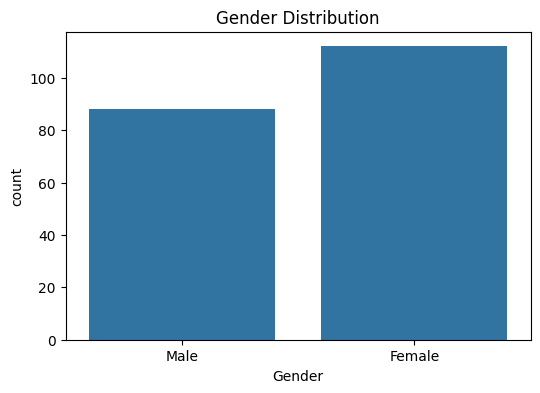

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(x='Gender', data=df)

plt.title("Gender Distribution")

plt.show()

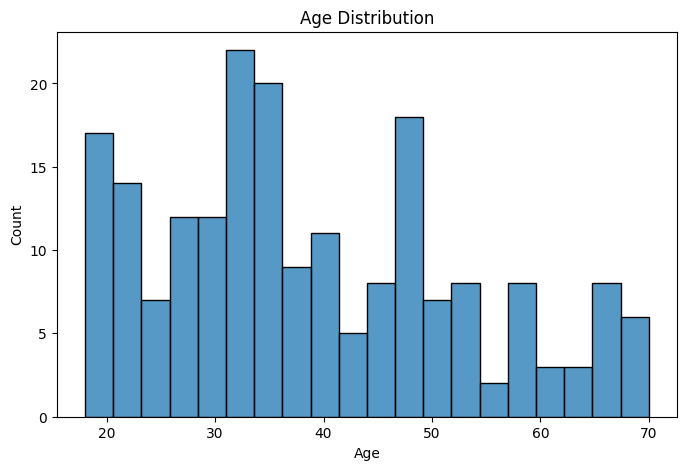

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20)

plt.title("Age Distribution")

plt.show()

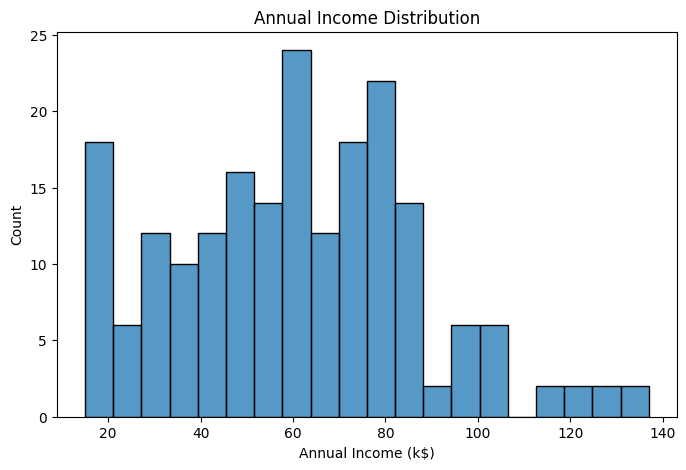

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df['Annual Income (k$)'], bins=20)

plt.title("Annual Income Distribution")

plt.show()

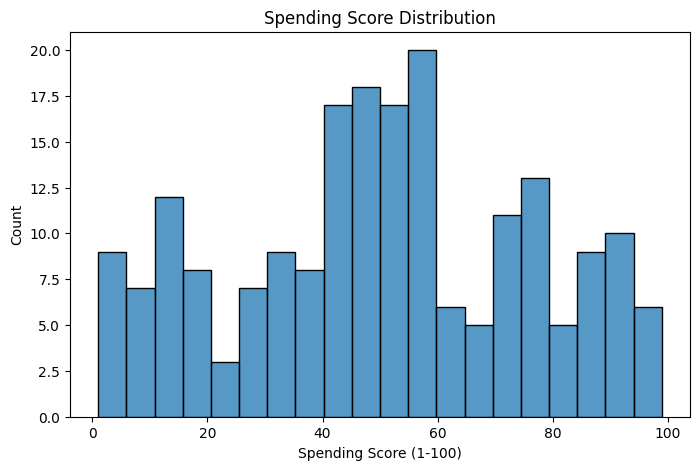

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df['Spending Score (1-100)'], bins=20)

plt.title("Spending Score Distribution")

plt.show()

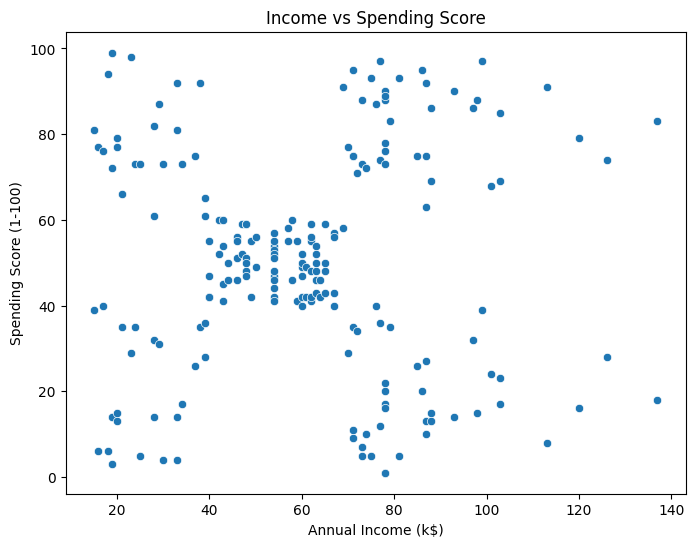

In [10]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)'
)

plt.title("Income vs Spending Score")

plt.show()

## Feature Selection

For customer segmentation, Age, Annual Income, and Spending Score are selected as clustering features.

In [11]:
X = df[['Age',
        'Annual Income (k$)',
        'Spending Score (1-100)']]

## Data Standardization

Feature scaling ensures that all variables contribute equally during clustering.

In [12]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Principal Component Analysis (PCA)

PCA reduces dimensionality while preserving most of the important information.

In [13]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:")

print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.44266167 0.33308378]


## Elbow Method

The Elbow Method is used to determine the optimal number of clusters.

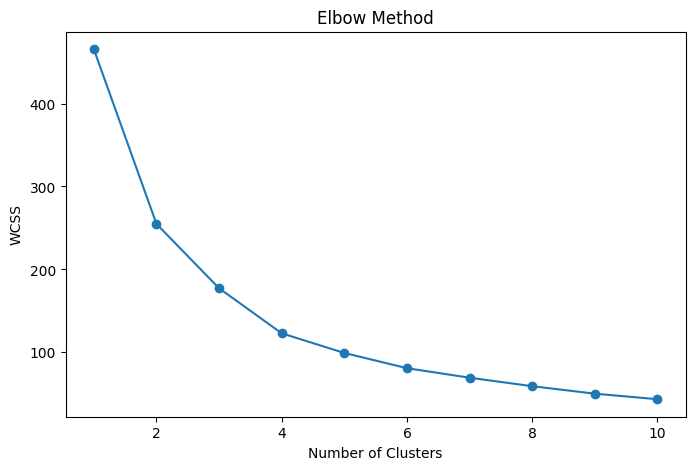

In [14]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_pca)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11),
         wcss,
         marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

## Silhouette Score Analysis

Silhouette Score measures cluster quality and separation.

In [15]:
for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_pca)

    score = silhouette_score(
        X_pca,
        labels
    )

    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.4256
K = 3, Silhouette Score = 0.4136
K = 4, Silhouette Score = 0.4209
K = 5, Silhouette Score = 0.3931
K = 6, Silhouette Score = 0.3775
K = 7, Silhouette Score = 0.3871
K = 8, Silhouette Score = 0.3976
K = 9, Silhouette Score = 0.3899
K = 10, Silhouette Score = 0.4038


## K-Means Clustering

Based on Elbow Method and Silhouette Score, the optimal number of clusters is selected.

In [16]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_pca)

df['Cluster'] = clusters

In [17]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,4
2,3,Female,20,16,6,0
3,4,Female,23,16,77,4
4,5,Female,31,17,40,4


## Cluster Visualization

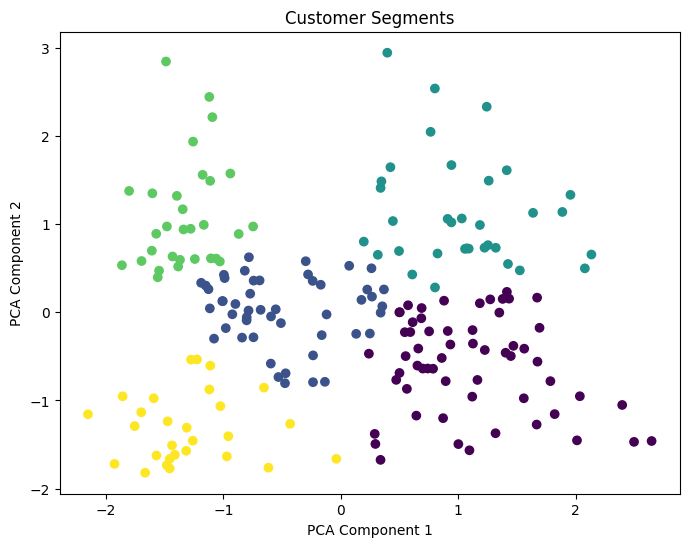

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)

plt.xlabel("PCA Component 1")

plt.ylabel("PCA Component 2")

plt.title("Customer Segments")

plt.show()

## Customer Personas

Customer personas help businesses understand different customer groups and design targeted marketing strategies.

In [19]:
cluster_summary = df.groupby(
    'Cluster'
).mean(
    numeric_only=True
)

cluster_summary

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,60.203390,53.559322,43.779661,38.508475
1,103.693878,30.489796,61.551020,52.612245
2,164.705882,43.264706,88.470588,18.617647
3,170.400000,31.733333,90.866667,83.266667
4,26.964286,24.750000,27.821429,73.535714


## Business Insights

### Cluster 0
Premium customers with high spending behavior.

### Cluster 1
Budget-conscious customers with low spending activity.

### Cluster 2
Young customers with moderate income and high engagement.

### Cluster 3
High-income customers with selective spending habits.

### Cluster 4
Regular customers with balanced purchasing behavior.

## Conclusion

Customer segmentation was successfully performed using PCA and K-Means Clustering.

The dataset was preprocessed, standardized, and reduced using Principal Component Analysis. The Elbow Method and Silhouette Score were used to determine the optimal number of clusters.

The resulting customer segments provide valuable business insights that can support targeted marketing, customer retention, and strategic decision-making.

---

## Tools & Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- PCA
- K-Means Clustering
- Google Colab